<center> 
<h1> Continuous time Mean-Variance Optimization </h1>
<p> Team members: <b>최승우, Nguyen Minh Duc, 문영진, 안영주</b> </p>
<p> IMEN786-01 - Advanced Investment Theory </p>
<p> Professor: <b>Jang Bong-Gyu</b> </p>
</center>

## Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from env import TradingEnv
from continuous_mvo import CapitalMarketLine, ContinuousMeanVarianceOptimization

Setting the visualization theme

In [3]:
sns.set_theme(style="whitegrid")

## Running the Continuous-time MVO formula by Zhou et al.

Create the trading environment with 10 stocks + 1 risky asset

The historical dates are for estimating the nominal annual interest and appriciation rate

The tradining dates are used for backtest the portfolio

In [4]:
env = TradingEnv(
    bonds_ticker='^TNX', # 10-Year Treasury Yield
    stocks_tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD'],
    # stocks_tickers=['NVDA'],
    historical_start_date='2018-01-01',
    historical_end_date='2023-01-01',
    start_trading_date='2023-01-01',
    end_trading_date='2024-01-01',
    use_sde=False,
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2018-01-01
            Historical End Date: 2023-01-01
            Start Trading Date: 2023-01-01
            End Trading Date: 2024-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.287461
MSFT     0.265836
GOOGL    0.148950
AMZN     0.133328
TSLA     0.565226
META     0.014218
NFLX     0.194735
NVDA     0.353043
INTC    -0.014489
AMD      0.516056
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.020638
dtype: float64
        


Initialize the Continuous-time MVO optimizer with an initial investment (`initial_funds`), and the desired rate of return (`target_return`)

In [5]:
optimizer = ContinuousMeanVarianceOptimization(env, initial_funds=1, target_return=0.20)

Using Equation (6.10), we can plot the capitial market line

In [6]:
print(f"Number of trading years: {optimizer.env.num_trading_years}")
print(f"Capital Market Line: {optimizer.capital_market_line}")

Number of trading years: 1.0
Capital Market Line: CapitalMarketLine(intercept=1.0208529129207315, slope=3.835569115860004)


Required standard deviation for target return: 4.67%


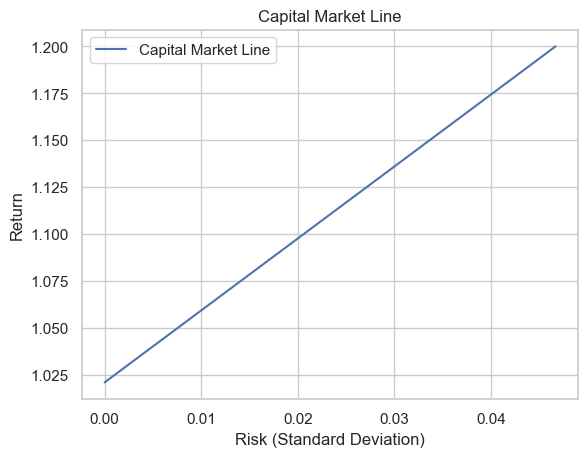

In [7]:
print(f"Required standard deviation for target return: {optimizer.sigma_T / optimizer.initial_funds * 100:.2f}%")
optimizer.capital_market_line.plot(optimizer.sigma_T)

Using Equation (5.12), we can obtain the optimal control for our portfolio

In [8]:
portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
print(f"Optimal Portfolio Weights: {portfolio_weights}")
print(f"Bonds Weight: {bonds_weight}")

# Check if the weights sum to 1
print("Total Weights:", np.sum(portfolio_weights) + bonds_weight)

Optimal Portfolio Weights: [ 0.43888211  0.82482452 -0.17491092 -0.40766888  0.16350013 -0.33238751
  0.06432692  0.03798479 -0.61564298  0.25963532]
Bonds Weight: 0.7414564979691701
Total Weights: 1.0


Visualizing the portfolio performance in 2 settings: With rebalancing and without rebalancing

In this example, we assume that the time between rebalances are equal

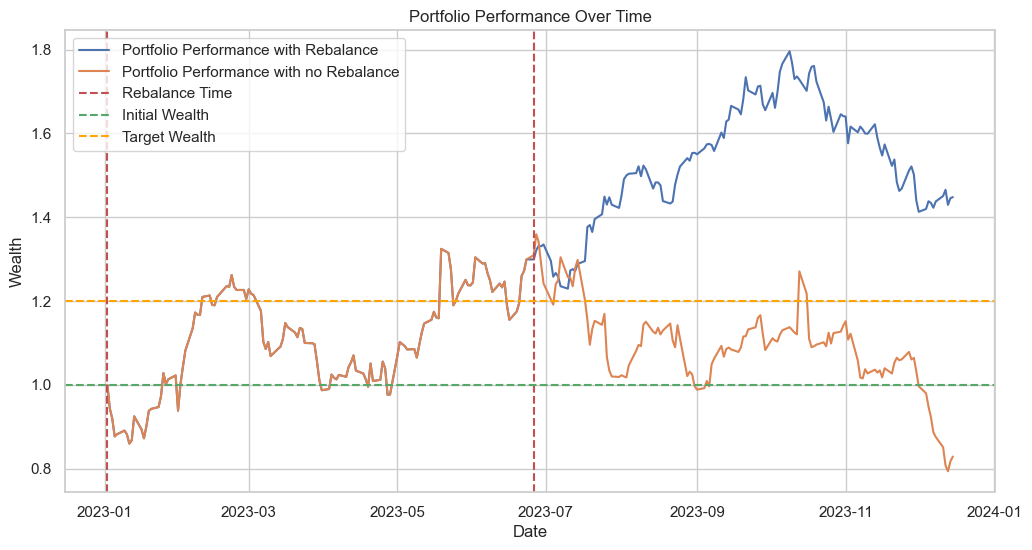

In [9]:
time_range = pd.date_range(start=env.start_trading_date, end=env.end_trading_date, freq='B')

# The number of rebalances
num_rebalances = 2
ts = np.linspace(0, env.num_trading_years, 1 + num_rebalances)

# The time between rebalances
dt = ts[1] - ts[0]
current_wealth = optimizer.initial_funds

# Plot the performance
plt.figure(figsize=(12, 6))

rebalanced_performances = []
rebalance_times = []
for t in ts[:-1]:
    portfolio_weights, bonds_weight = optimizer.get_control(t=t, x=current_wealth)
    combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
    performance = env.get_wealth_after_trading(combined_weights, t0=t, t1=t+dt) * current_wealth
    rebalanced_performances.extend(performance)
    current_wealth = performance[-1]
    rebalance_time = (t / ts[-1])
    rebalance_times.append(rebalance_time)

plt.plot(time_range[:len(rebalanced_performances)], rebalanced_performances, label='Portfolio Performance with Rebalance')

portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
no_rebalanced_performances = env.get_wealth_after_trading(combined_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
plt.plot(time_range[:len(no_rebalanced_performances)], no_rebalanced_performances, label='Portfolio Performance with no Rebalance')

for idx, rebalance_time in enumerate(rebalance_times):
    if idx == 0:
        plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--', label='Rebalance Time')    
    else:
        plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--')

plt.axhline(y=optimizer.initial_funds, color='g', linestyle='--', label='Initial Wealth')
plt.axhline(y=optimizer.target_wealth, color='orange', linestyle='--', label='Target Wealth')

plt.title('Portfolio Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Wealth')
plt.legend()
plt.show()

## Computing the Sharpe Ratio on the performances of the 2 strategies

In [10]:
def calculate_sharpe_ratio(performance):
    returns = np.diff(performance) / performance[:-1]
    mean_return = np.mean(returns) * 252  # Annualize the mean return
    std_return = np.std(returns) * np.sqrt(252)  # Annualize the standard deviation
    sharpe_ratio = mean_return / std_return if std_return != 0 else 0
    return mean_return, std_return, sharpe_ratio

### Rebalancing strategy

In [11]:
rebalanced_mean, rebalanced_std, rebalanced_sharpe = calculate_sharpe_ratio(rebalanced_performances)
print(f"Rebalanced Portfolio Average Return: {rebalanced_mean * 100:.2f}%")
print(f"Rebalanced Portfolio Standard Deviation: {rebalanced_std * 100:.2f}%")
print(f"Rebalanced Portfolio Sharpe Ratio: {rebalanced_sharpe:.2f}")

Rebalanced Portfolio Average Return: 45.46%
Rebalanced Portfolio Standard Deviation: 40.14%
Rebalanced Portfolio Sharpe Ratio: 1.13


### No rebalancing strategy

In [12]:
no_rebalanced_mean, no_rebalanced_std, no_rebalanced_sharpe = calculate_sharpe_ratio(no_rebalanced_performances)
print(f"Rebalanced Portfolio Average Return: {no_rebalanced_mean * 100:.2f}%")
print(f"Rebalanced Portfolio Standard Deviation: {no_rebalanced_std * 100:.2f}%")
print(f"Rebalanced Portfolio Sharpe Ratio: {no_rebalanced_sharpe:.2f}")

Rebalanced Portfolio Average Return: -7.31%
Rebalanced Portfolio Standard Deviation: 48.44%
Rebalanced Portfolio Sharpe Ratio: -0.15


## Code to run multiple experiments

In [13]:
def run_exp(
    bonds_ticker: str,
    stocks_tickers: list[str],
    historical_start_date: str,
    historical_end_date: str,
    start_trading_date: str,
    end_trading_date: str,
    initial_funds: float = 1_000_000,
    target_return: float = 0.10,
    num_rebalances: int = 2,
):
    """
    Run the experiment with the given parameters.
    """

    # Create the trading environment
    env = TradingEnv(
        bonds_ticker=bonds_ticker,
        stocks_tickers=stocks_tickers,
        historical_start_date=historical_start_date,
        historical_end_date=historical_end_date,
        start_trading_date=start_trading_date,
        end_trading_date=end_trading_date,
    )
    
    # Create the continuous-time mean-variance optimizer
    optimizer = ContinuousMeanVarianceOptimization(env, initial_funds=initial_funds, target_return=target_return)

    print(f"Number of trading years: {optimizer.env.num_trading_years}")
    print(f"Capital Market Line: {optimizer.capital_market_line}")    
    print(f"Required standard deviation for target return: {optimizer.sigma_T / optimizer.initial_funds * 100:.2f}%")
    optimizer.capital_market_line.plot(optimizer.sigma_T)

    time_range = pd.date_range(start=env.start_trading_date, end=env.end_trading_date, freq='B')

    # The number of rebalances
    ts = np.linspace(0, env.num_trading_years, 1 + num_rebalances)

    # The time between rebalances
    dt = ts[1] - ts[0]
    current_wealth = optimizer.initial_funds

    # Plot the performance
    plt.figure(figsize=(12, 6))

    rebalanced_performances = []
    rebalance_times = []
    for t in ts[:-1]:
        portfolio_weights, bonds_weight = optimizer.get_control(t=t, x=current_wealth)
        combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
        performance = env.get_wealth_after_trading(combined_weights, t0=t, t1=t+dt) * current_wealth
        rebalanced_performances.extend(performance)
        current_wealth = performance[-1]
        rebalance_time = (t / ts[-1])
        rebalance_times.append(rebalance_time)

    plt.plot(time_range[:len(rebalanced_performances)], rebalanced_performances, label='Portfolio Performance with Rebalance')

    portfolio_weights, bonds_weight = optimizer.get_control(t=0.0, x=optimizer.initial_funds)
    combined_weights = np.concatenate([portfolio_weights, [bonds_weight]])
    no_rebalanced_performances = env.get_wealth_after_trading(combined_weights, t0=0.0, t1=env.num_trading_years) * optimizer.initial_funds
    plt.plot(time_range[:len(no_rebalanced_performances)], no_rebalanced_performances, label='Portfolio Performance with no Rebalance')

    for idx, rebalance_time in enumerate(rebalance_times):
        if idx == 0:
            plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--', label='Rebalance Time')    
        else:
            plt.axvline(x=time_range[int(rebalance_time * len(rebalanced_performances))], color='r', linestyle='--')

    plt.axhline(y=optimizer.initial_funds, color='g', linestyle='--', label='Initial Wealth')
    plt.axhline(y=optimizer.target_wealth, color='orange', linestyle='--', label='Target Wealth')

    plt.title('Portfolio Performance Over Time')
    plt.xlabel('Date')
    plt.ylabel('Wealth')
    plt.legend()
    plt.show()

    # Calculate the Sharpe ratio
    rebalanced_mean, rebalanced_std, rebalanced_sharpe = calculate_sharpe_ratio(rebalanced_performances)
    print(f"Rebalanced Portfolio Average Return: {rebalanced_mean * 100:.2f}%")
    print(f"Rebalanced Portfolio Standard Deviation: {rebalanced_std * 100:.2f}%")
    print(f"Rebalanced Portfolio Sharpe Ratio: {rebalanced_sharpe:.2f}")
    print("=" * 50)
    no_rebalanced_mean, no_rebalanced_std, no_rebalanced_sharpe = calculate_sharpe_ratio(no_rebalanced_performances)
    print(f"Rebalanced Portfolio Average Return: {no_rebalanced_mean * 100:.2f}%")
    print(f"Rebalanced Portfolio Standard Deviation: {no_rebalanced_std * 100:.2f}%")
    print(f"Rebalanced Portfolio Sharpe Ratio: {no_rebalanced_sharpe:.2f}")

### 1-year investment period

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2018-01-01
            Historical End Date: 2023-01-01
            Start Trading Date: 2023-01-01
            End Trading Date: 2024-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.287461
MSFT     0.265836
GOOGL    0.148950
AMZN     0.133328
TSLA     0.565226
META     0.014218
NFLX     0.194735
NVDA     0.353043
INTC    -0.014489
AMD      0.516056
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.020638
dtype: float64
        
Number of trading years: 1.0
Capital Market Line: CapitalMarketLine(intercept=1020852.9129207316, slope=3.835569115860004)
Required standard deviation for target return: 4.67%


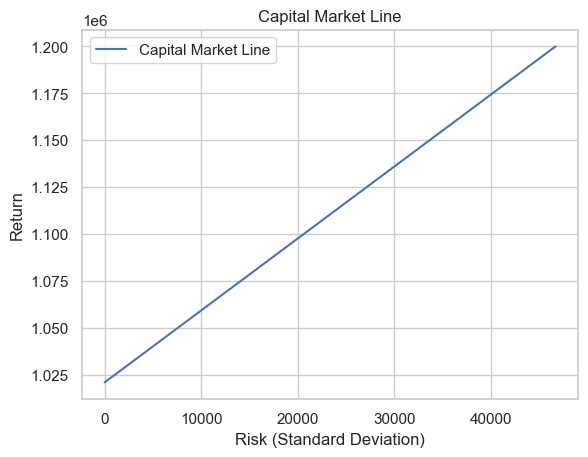

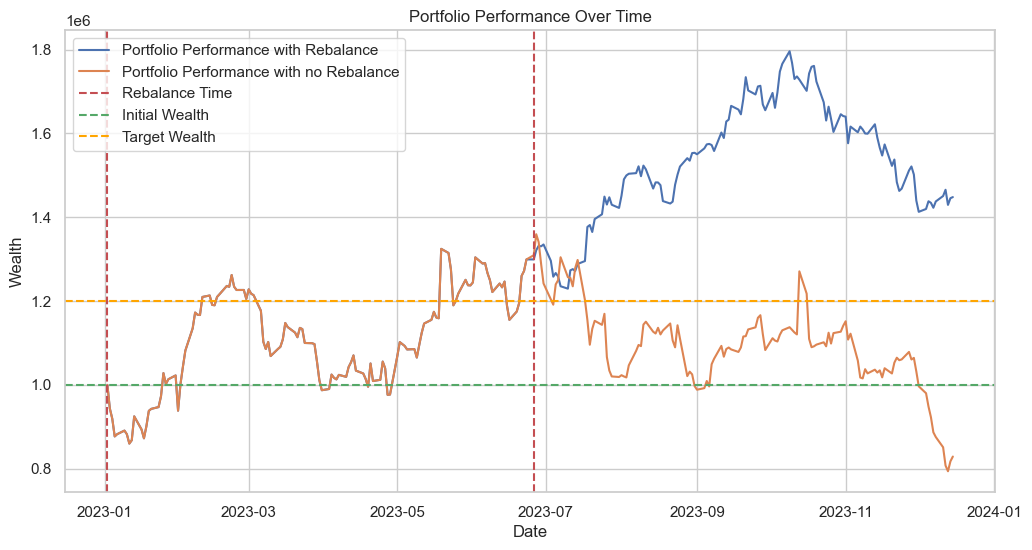

Rebalanced Portfolio Average Return: 45.46%
Rebalanced Portfolio Standard Deviation: 40.14%
Rebalanced Portfolio Sharpe Ratio: 1.13
Rebalanced Portfolio Average Return: -7.31%
Rebalanced Portfolio Standard Deviation: 48.44%
Rebalanced Portfolio Sharpe Ratio: -0.15


In [14]:
run_exp(
    bonds_ticker='^TNX', # 10-Year Treasury Yield
    stocks_tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD'],
    historical_start_date='2018-01-01',
    historical_end_date='2023-01-01',
    start_trading_date='2023-01-01',
    end_trading_date='2024-01-01',
    initial_funds=1_000_000,
    target_return=0.20, # 20% target return
    num_rebalances=2,
)

### 3-year investment period

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

            Bonds Ticker: ^TNX
            Stocks Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD']
            Historical Start Date: 2017-01-01
            Historical End Date: 2022-01-01
            Start Trading Date: 2022-01-01
            End Trading Date: 2025-01-01
            Use SDE: False
            Nominal Annual Appreciation: Ticker
AAPL     0.421515
MSFT     0.389476
GOOGL    0.292530
AMZN     0.341209
TSLA     0.821496
META     0.267399
NFLX     0.383656
NVDA     0.604130
INTC     0.154596
AMD      0.665488
dtype: float64
            Nominal Annual Interest Rate: Ticker
^TNX    0.019384
dtype: float64
        
Number of trading years: 3.0027397260273974
Capital Market Line: CapitalMarketLine(intercept=1019572.9550722665, slope=5.664682269089989)
Required standard deviation for target return: 3.19%


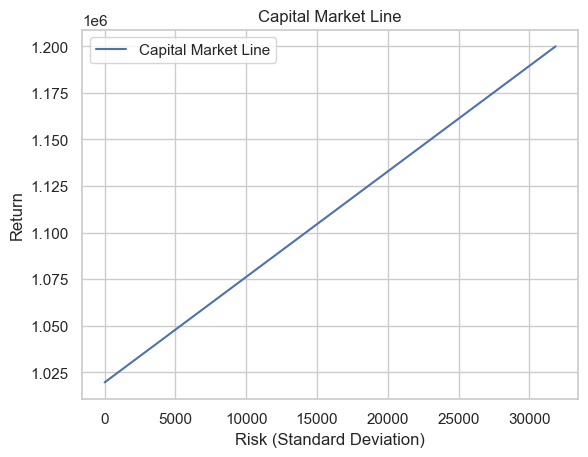

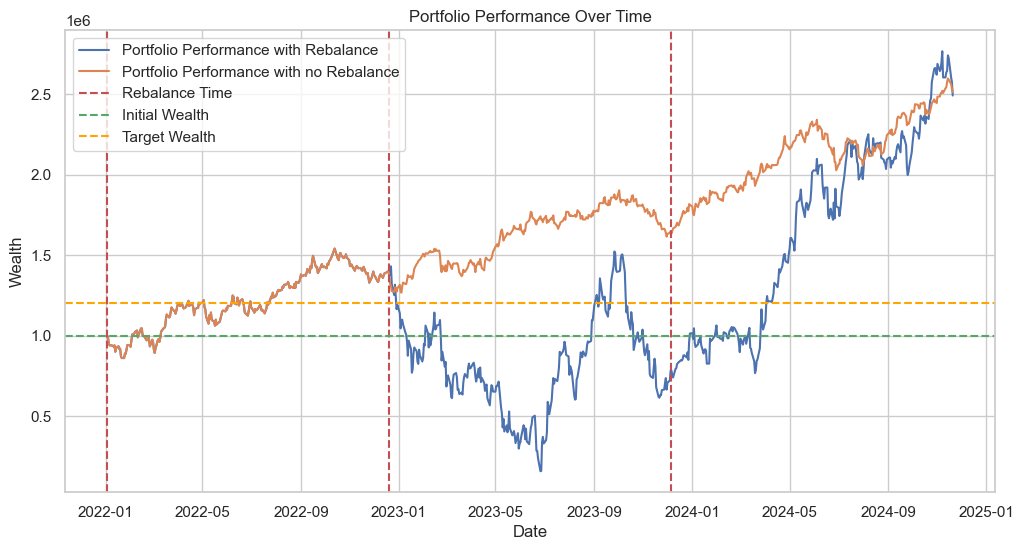

Rebalanced Portfolio Average Return: 87.81%
Rebalanced Portfolio Standard Deviation: 114.40%
Rebalanced Portfolio Sharpe Ratio: 0.77
Rebalanced Portfolio Average Return: 34.03%
Rebalanced Portfolio Standard Deviation: 25.02%
Rebalanced Portfolio Sharpe Ratio: 1.36


In [15]:
run_exp(
    bonds_ticker='^TNX', # 10-Year Treasury Yield
    stocks_tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NFLX', 'NVDA', 'INTC', 'AMD'],
    historical_start_date='2017-01-01',
    historical_end_date='2022-01-01',
    start_trading_date='2022-01-01',
    end_trading_date='2025-01-01',
    initial_funds=1_000_000,
    target_return=0.20, # 20% target return
    num_rebalances=3,
)